In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (11, 7)


In [4]:
cars = pd.read_csv("data/raw/cars_sampled.csv")
cars.head()

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,postalCode,lastSeen
0,30/03/2016 13:51,Zu_verkaufen,private,offer,4450,test,limousine,2003,manual,150,3er,150000,3,diesel,bmw,NaN,30/03/2016 0:00,20257,7/4/2016 4:44
1,7/3/2016 9:54,Volvo_XC90_2.4D_Summum,private,offer,13299,control,suv,2005,manual,163,xc_reihe,150000,6,diesel,volvo,no,7/3/2016 0:00,88045,26/03/2016 13:17
2,1/4/2016 0:57,Volkswagen_Touran,private,offer,3200,test,bus,2003,manual,101,touran,150000,11,diesel,volkswagen,NaN,31/03/2016 0:00,27449,1/4/2016 8:40
3,19/03/2016 17:50,Seat_Ibiza_1.4_16V_Reference,private,offer,4500,control,small car,2006,manual,86,ibiza,60000,12,petrol,seat,no,19/03/2016 0:00,34537,7/4/2016 4:44
4,16/03/2016 14:51,Volvo_XC90_D5_Aut._RDesign_R_Design_AWD_GSHD_S...,private,offer,18750,test,suv,2008,automatic,185,xc_reihe,150000,11,diesel,volvo,no,16/03/2016 0:00,55270,1/4/2016 23:18


In [5]:
cars.shape

(50001, 19)

In [6]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50001 entries, 0 to 50000
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   dateCrawled          50001 non-null  object
 1   name                 50001 non-null  object
 2   seller               50001 non-null  object
 3   offerType            50001 non-null  object
 4   price                50001 non-null  int64 
 5   abtest               50001 non-null  object
 6   vehicleType          44813 non-null  object
 7   yearOfRegistration   50001 non-null  int64 
 8   gearbox              47177 non-null  object
 9   powerPS              50001 non-null  int64 
 10  model                47243 non-null  object
 11  kilometer            50001 non-null  int64 
 12  monthOfRegistration  50001 non-null  int64 
 13  fuelType             45498 non-null  object
 14  brand                50001 non-null  object
 15  notRepairedDamage    40285 non-null  object
 16  date

In [7]:
cars.describe()

,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,postalCode
count,5.000100e+04,50001.000000,50001.000000,50001.000000,50001.000000,50001.000000
mean,6.559865e+03,2005.544229,116.496130,125613.687726,5.743725,50775.216696
std,8.581847e+04,122.991832,230.567709,40205.234483,3.711345,25743.701933
min,0.000000e+00,1000.000000,0.000000,5000.000000,0.000000,1067.000000
25%,1.150000e+03,1999.000000,69.000000,125000.000000,3.000000,30559.000000
50%,2.950000e+03,2003.000000,105.000000,150000.000000,6.000000,49504.000000
75%,7.190000e+03,2008.000000,150.000000,150000.000000,9.000000,71404.000000
max,1.234568e+07,9999.000000,19312.000000,150000.000000,12.000000,99998.000000


In [8]:
cars.isnull().sum().sort_values(ascending=False)

notRepairedDamage      9716
vehicleType            5188
fuelType               4503
gearbox                2824
model                  2758
dateCrawled               0
name                      0
seller                    0
price                     0
abtest                    0
offerType                 0
powerPS                   0
yearOfRegistration        0
monthOfRegistration       0
kilometer                 0
brand                     0
dateCreated               0
postalCode                0
lastSeen                  0
dtype: int64

In [9]:
drop_cols = ['name','dateCrawled','dateCreated','postalCode','lastSeen']
cars = cars.drop(columns=drop_cols)
cars.head()


,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage
0,private,offer,4450,test,limousine,2003,manual,150,3er,150000,3,diesel,bmw,NaN
1,private,offer,13299,control,suv,2005,manual,163,xc_reihe,150000,6,diesel,volvo,no
2,private,offer,3200,test,bus,2003,manual,101,touran,150000,11,diesel,volkswagen,NaN
3,private,offer,4500,control,small car,2006,manual,86,ibiza,60000,12,petrol,seat,no
4,private,offer,18750,test,suv,2008,automatic,185,xc_reihe,150000,11,diesel,volvo,no


In [10]:
cars.duplicated().sum()

np.int64(470)

In [11]:
cars = cars.drop_duplicates()
cars.shape

(49531, 14)

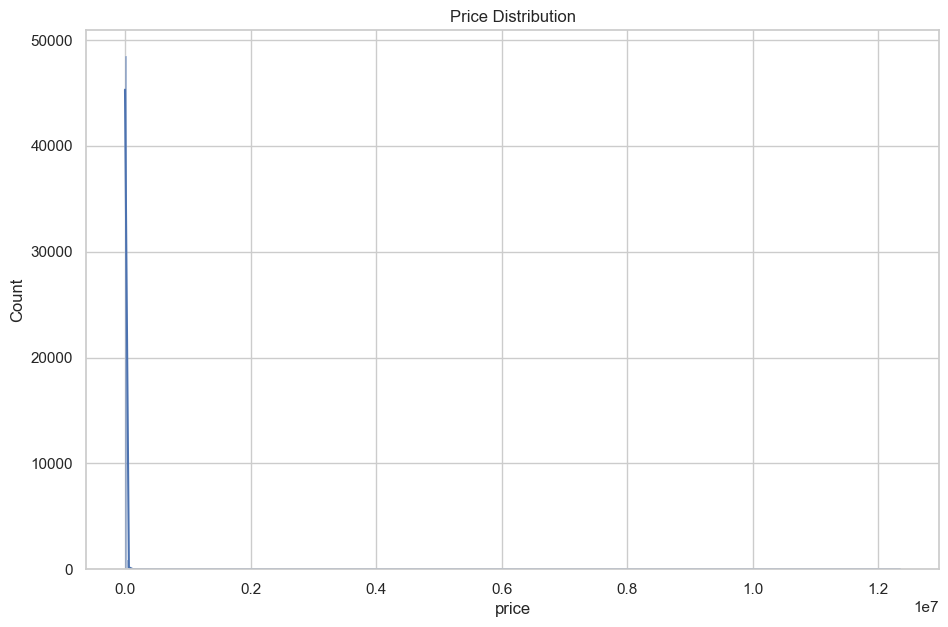

In [12]:
sns.histplot(cars['price'], kde=True)
plt.title("Price Distribution")
plt.show()

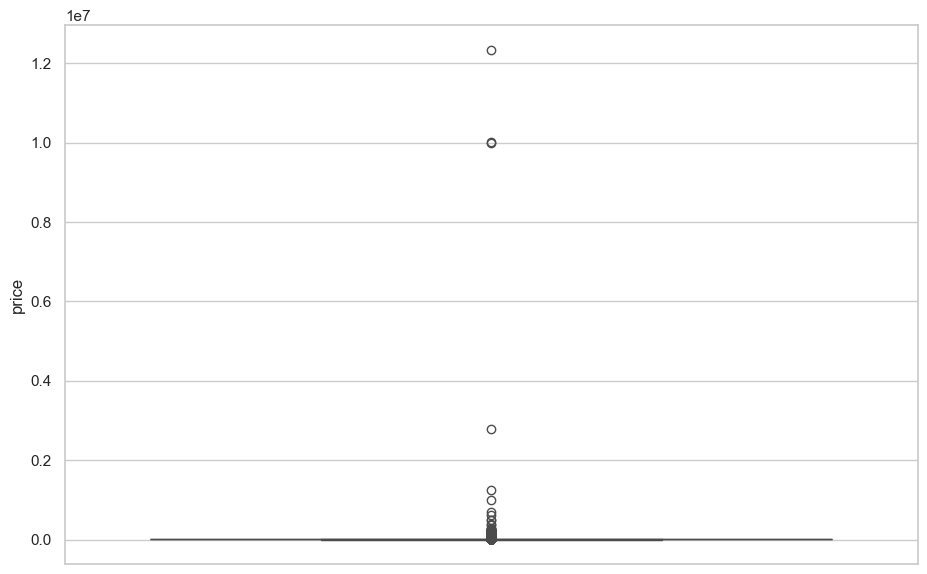

In [13]:
sns.boxplot(y=cars['price'])
plt.show()

In [14]:
cars[
    (cars['yearOfRegistration'] < 1950) | 
    (cars['yearOfRegistration'] > 2018)
].shape

(64, 14)

In [15]:
cars[
    (cars['price'] < 100) | 
    (cars['price'] > 150000)
].shape


(1782, 14)

In [16]:
cars[
    (cars['powerPS'] < 10) | 
    (cars['powerPS'] > 500)
].shape


(5680, 14)

In [17]:
cars = cars[
    (cars['price'].between(100, 150000)) &
    (cars['yearOfRegistration'].between(1950, 2018)) &
    (cars['powerPS'].between(10, 500))
]

cars.shape


(42772, 14)

In [18]:
cars['monthOfRegistration'] = cars['monthOfRegistration'] / 12
cars['Age'] = (2018 - cars['yearOfRegistration']) + cars['monthOfRegistration']
cars['Age'] = cars['Age'].round(2)

cars[['yearOfRegistration','monthOfRegistration','Age']].head()

,yearOfRegistration,monthOfRegistration,Age
0,2003,0.250000,15.25
1,2005,0.500000,13.50
2,2003,0.916667,15.92
3,2006,1.000000,13.00
4,2008,0.916667,10.92


In [19]:
cars = cars.drop(columns=['yearOfRegistration','monthOfRegistration'])
cars.head()

,seller,offerType,price,abtest,vehicleType,gearbox,powerPS,model,kilometer,fuelType,brand,notRepairedDamage,Age
0,private,offer,4450,test,limousine,manual,150,3er,150000,diesel,bmw,NaN,15.25
1,private,offer,13299,control,suv,manual,163,xc_reihe,150000,diesel,volvo,no,13.50
2,private,offer,3200,test,bus,manual,101,touran,150000,diesel,volkswagen,NaN,15.92
3,private,offer,4500,control,small car,manual,86,ibiza,60000,petrol,seat,no,13.00
4,private,offer,18750,test,suv,automatic,185,xc_reihe,150000,diesel,volvo,no,10.92


In [20]:
cat_cols = cars.select_dtypes(include='object').columns

for col in cat_cols:
    print("\n", col)
    print(cars[col].value_counts(normalize=True).head())


 seller
seller
private       0.999977
commercial    0.000023
Name: proportion, dtype: float64

 offerType
offerType
offer    1.0
Name: proportion, dtype: float64

 abtest
abtest
test       0.517348
control    0.482652
Name: proportion, dtype: float64

 vehicleType
vehicleType
limousine        0.294415
small car        0.232730
station wagon    0.202426
bus              0.090159
cabrio           0.069982
Name: proportion, dtype: float64

 gearbox
gearbox
manual       0.776168
automatic    0.223832
Name: proportion, dtype: float64

 model
model
golf      0.084646
others    0.070579
3er       0.060405
polo      0.036506
corsa     0.033732
Name: proportion, dtype: float64

 fuelType
fuelType
petrol    0.659838
diesel    0.319950
lpg       0.017175
cng       0.001742
hybrid    0.000896
Name: proportion, dtype: float64

 brand
brand
volkswagen       0.213551
bmw              0.113813
opel             0.104905
mercedes_benz    0.096652
audi             0.093145
Name: proportion, dtype: float

In [21]:
for col in cars.columns:
    if cars[col].dtype == 'object':
        cars[col].fillna(cars[col].mode()[0], inplace=True)
    else:
        cars[col].fillna(cars[col].median(), inplace=True)

cars.isnull().sum()

seller               0
offerType            0
price                0
abtest               0
vehicleType          0
gearbox              0
powerPS              0
model                0
kilometer            0
fuelType             0
brand                0
notRepairedDamage    0
Age                  0
dtype: int64

In [24]:
cars.to_csv("data/processed/cars_cleaned.csv", index=False)